# Raisin Variety Classification

**Project Link:** https://www.kaggle.com/datasets/nimapourmoradi/raisin-binary-classification

## Overview

The goal of this project is to build a binary classification model that distinguishes between two raisin varieties: Besni and Kecimen. Each raisin is described by seven physical measurements like Area, Perimeter, Eccentricity, etc. A Logistic Regression baseline is compared against a Random Forest classifier, using Accuracy and ROC-AUC as the primary metrics. Logistic Regression is the best model and achieved 86.1% accuracy and 0.96 AUC on the held-out test set, with Random Forest performing comparably at 87.2% accuracy and 0.94 AUC.

---
## 1. Data

**Type:** Tabular CSV — each row is one raisin grain.  
**Input:** 7 numerical morphological features (Area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, Extent, Perimeter).  
**Output:** Binary class label — `Besni` (1) or `Kecimen` (0).  
**Size:** 900 samples total.  
**Split:** 60% Train (540 samples) · 20% Validation (180 samples) · 20% Test (180 samples).

### 1a. Data Loading and Initial Look

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             classification_report)

# Load data 
df = pd.read_csv('Raisin_Dataset.csv')

print(f"Rows: {df.shape[0]}   Features (incl. target): {df.shape[1]}")
print()
print("First 5 rows:")
df.head()

Rows: 900   Features (incl. target): 8

First 5 rows:


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [20]:
print("Last 5 rows:")
df.tail()

Last 5 rows:


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
895,83248,430.077308,247.838695,0.817263,85839,0.668793,1129.072,Besni
896,87350,440.735698,259.293149,0.808629,90899,0.636476,1214.252,Besni
897,99657,431.706981,298.837323,0.721684,106264,0.741099,1292.828,Besni
898,93523,476.344094,254.176054,0.845739,97653,0.658798,1258.548,Besni
899,85609,512.081774,215.271976,0.907345,89197,0.632020,1272.862,Besni


In [21]:
# Prints out the basic categories + missing values
df.info()
print()
print("Missing values per column:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    str    
dtypes: float64(5), int64(2), str(1)
memory usage: 56.4 KB

Missing values per column:
Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64


In [3]:
df.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


In [24]:
# Feature summary table
rows = [] # Create an empty list to store data for each column
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        ftype = "Numerical" # Checks if the column contains numbers
        val_range = f"{df[col].min():.2f} – {df[col].max():.2f}"
        outlier_q = df[col].quantile([0.25, 0.75])
        iqr = outlier_q[0.75] - outlier_q[0.25]
        n_outliers = ((df[col] < outlier_q[0.25] - 1.5 * iqr) |
                      (df[col] > outlier_q[0.75] + 1.5 * iqr)).sum() # Counts any values that are outliers
    else:
        ftype = "Categorical"
        val_range = ", ".join(df[col].unique()) # Formats the spread of data from the smallest to the largest value
        n_outliers = "N/A"

    rows.append({
        "Feature": col,
        "Type": ftype,
        "Values / Range": val_range,
        "Missing": df[col].isnull().sum(),
        "Outliers (IQR)": n_outliers    # Handles non-numeric columns and saves the gathered information into a dictionary for this feature.
    })

feature_table = pd.DataFrame(rows)
print(feature_table.to_string(index=False))

        Feature        Type       Values / Range  Missing Outliers (IQR)
           Area   Numerical 25387.00 – 235047.00        0             41
MajorAxisLength   Numerical      225.63 – 997.29        0             17
MinorAxisLength   Numerical      143.71 – 492.28        0             26
   Eccentricity   Numerical          0.35 – 0.96        0             43
     ConvexArea   Numerical 26139.00 – 278217.00        0             42
         Extent   Numerical          0.38 – 0.84        0             21
      Perimeter   Numerical     619.07 – 2697.75        0             17
          Class Categorical       Kecimen, Besni        0            N/A


In [25]:
# Class balance check, checks how many raisins of each type are in the dataset
print("Class distribution:")
print(df['Class'].value_counts())
print()
print("Class balance (%):")
print(df['Class'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%') # value_counts(normalize=True) turns counts into decimals

Class distribution:
Class
Kecimen    450
Besni      450
Name: count, dtype: int64

Class balance (%):
Class
Kecimen    50.0%
Besni      50.0%
Name: proportion, dtype: str


---
## 2. Data Visualization

Below the distribution of each feature is compared, split by class.  
Features where the two distributions are well-separated are the most informative for classification.

**Observations:**
- `Area`, `ConvexArea`, `MajorAxisLength`, and `Perimeter` show clear separation. Besni raisins tend to be larger.
- `Eccentricity` and `Extent` overlap more, suggesting they are weaker individual predictors.

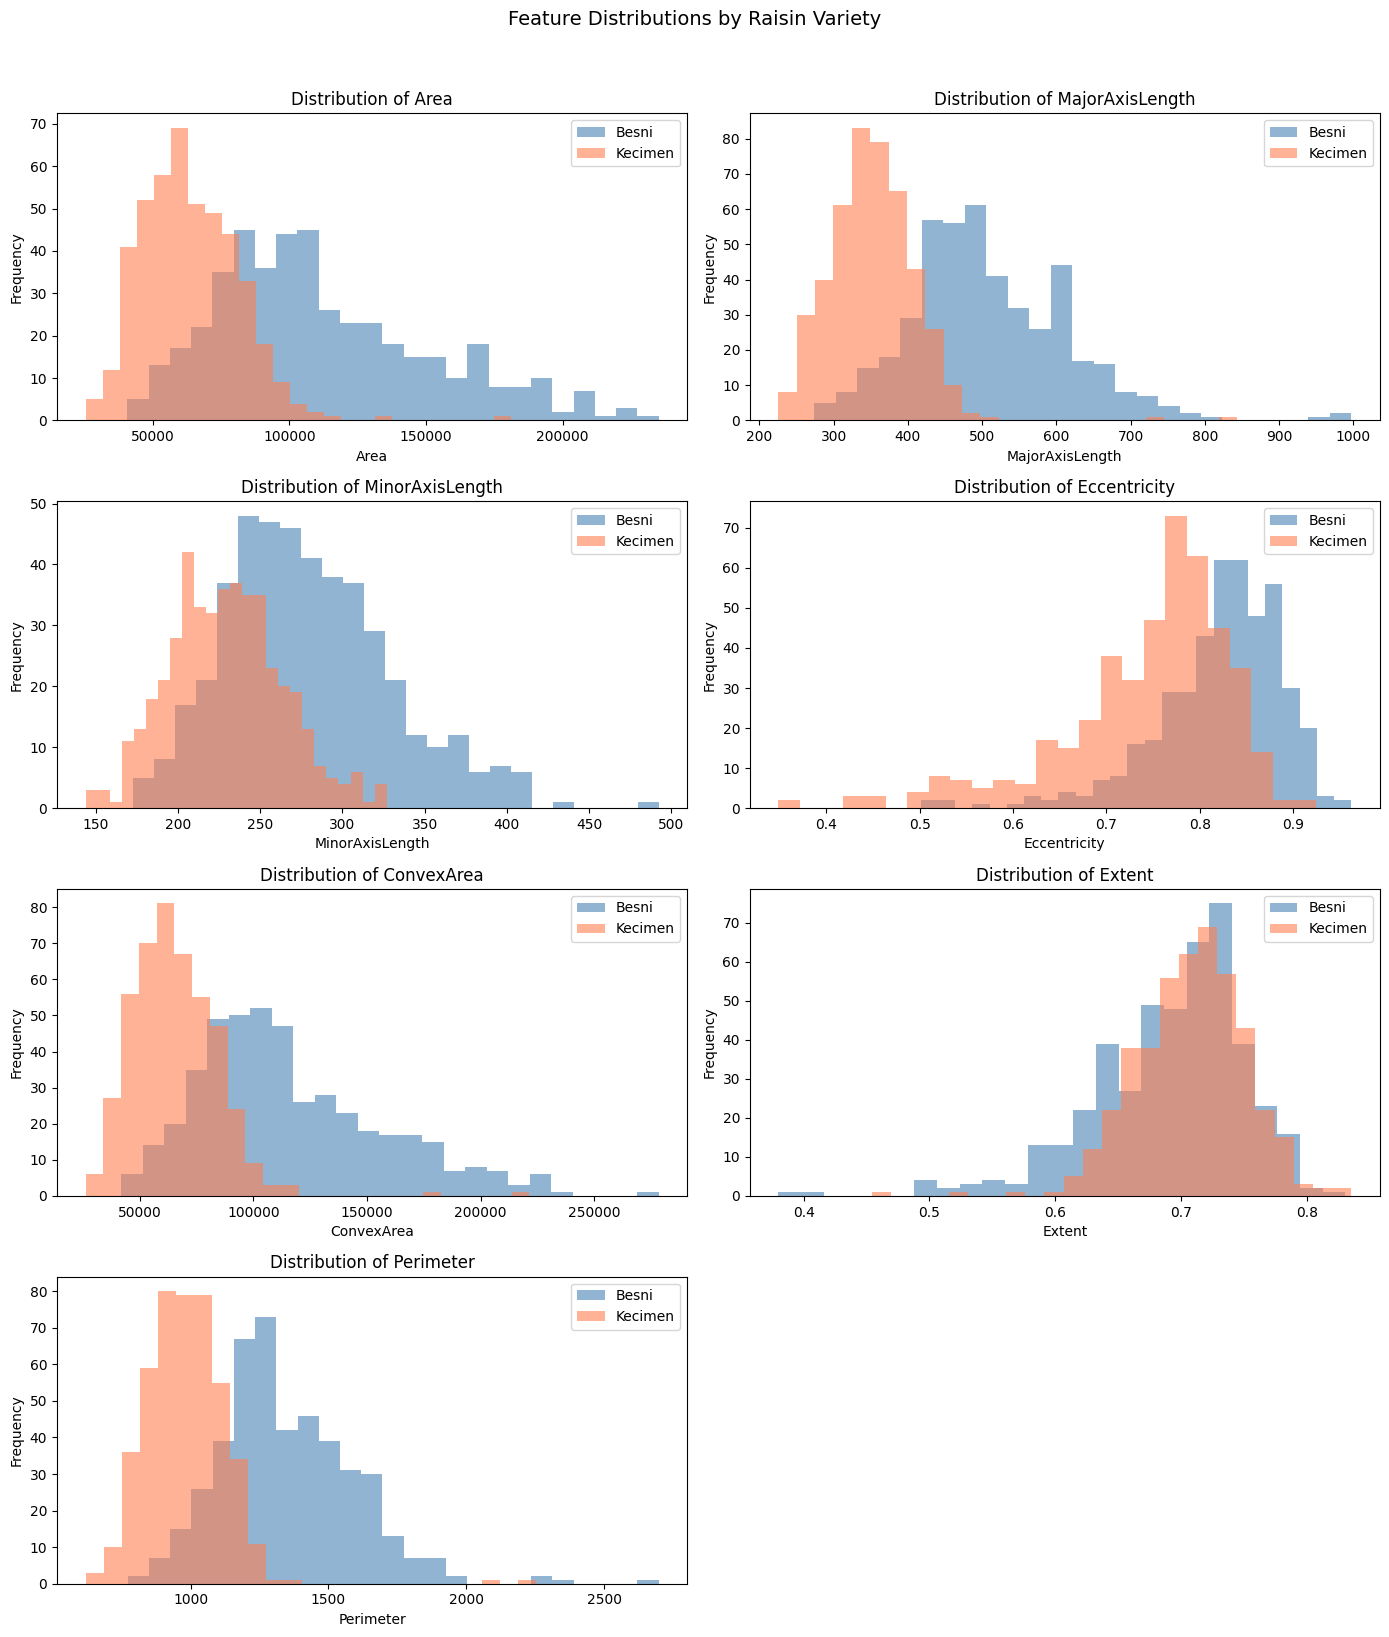

In [27]:
besni   = df[df['Class'] == 'Besni'] # Separates the dataset into two groups based on the raisin variety
kecimen = df[df['Class'] == 'Kecimen']
num_cols = df.select_dtypes(include='number').columns.tolist() # Identifies all columns that contain numbers

n_cols = 2
n_rows = (len(num_cols) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten() # Flatten the grid from a 2D matrix to make it easier to loop through

for i, col in enumerate(num_cols):
    axes[i].hist(besni[col],   bins=25, alpha=0.6, label='Besni',   color='steelblue')
    axes[i].hist(kecimen[col], bins=25, alpha=0.6, label='Kecimen', color='coral')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

# Hides any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Raisin Variety', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

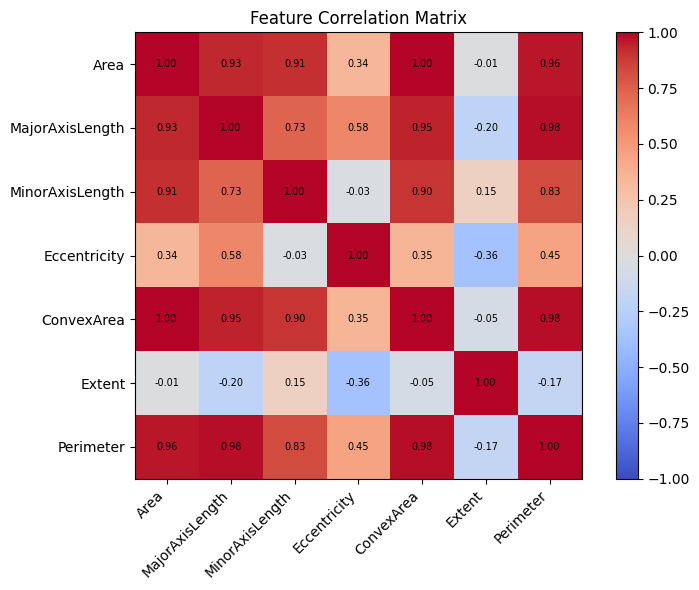

In [29]:
# Calculate the correlation between all numeric measurements
import matplotlib.pyplot as plt
import numpy as np

corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right') # Rotates the bottom labels so they don't overlap
ax.set_yticklabels(num_cols)
ax.set_title('Feature Correlation Matrix')

for i in range(len(num_cols)): # Loops through the data to write the actual correlation numbers inside each square
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()
# Area, ConvexArea, MajorAxisLength, and Perimeter are highly correlated (>0.97), features are similar.

---
## 3. Data Cleaning & Preprocessing

**Steps taken:**
1. **No missing values** — confirmed above so no further action is needed
2. **Outlier treatment** — IQR based outliers exist but are real structual measurements so they are retained
3. **Target encoding** — `Class` → `Class_Encoded` (Kecimen = 0, Besni = 1).
4. **Standard Scaling** — all 7 features are scaled to zero mean, unit variance. This is important for Logistic Regression, as it is sensitive to feature magnitude.
5. **No one-hot encoding needed** — the only categorical column is the target, which is binary-encoded directly.

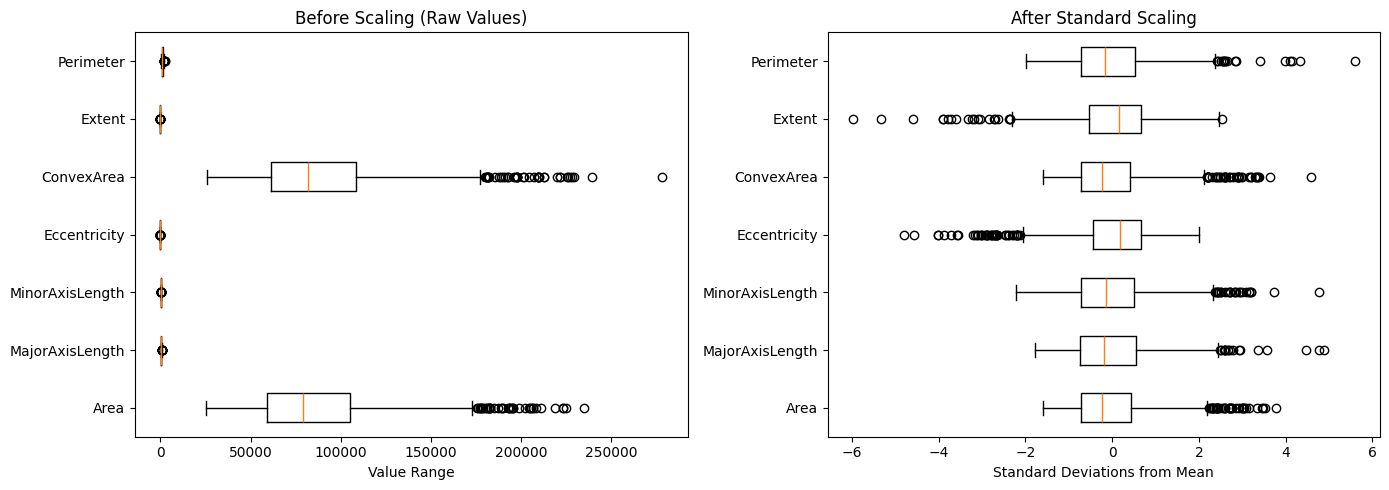

In [32]:
# Target encoding 
df['Class_Encoded'] = df['Class'].map({'Kecimen': 0, 'Besni': 1})
# Converted'Kecimen' to 0 and 'Besni' to 1 so the model has a clear goal.
X = df.drop(['Class', 'Class_Encoded'], axis=1)
y = df['Class_Encoded'] # Separates the dataset into X (the measurements) and y (variety)

# Standard Scaling, shifts the data so the average is 0 and the spread is measured in standard deviations.
scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(X) # Calculates the scaling math and apply it to the data
X_scaled = pd.DataFrame(X_scaled_arr, columns=X.columns)

# Before / After comparison using boxplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.boxplot(X.values, tick_labels=X.columns, vert=False) # Plot 1, the raw values before scaling
ax1.set_title("Before Scaling (Raw Values)")
ax1.set_xlabel("Value Range")

ax2.boxplot(X_scaled.values, tick_labels=X_scaled.columns, vert=False) # Plot 2, the values after standard scaling
ax2.set_title("After Standard Scaling")
ax2.set_xlabel("Standard Deviations from Mean")

plt.tight_layout()
plt.show()

---
## 4. Machine Learning

### 4a. Problem Formulation & Data Splitting

- **Input:** 7 scaled numerical features.
- **Output:** Binary label (0 = Kecimen, 1 = Besni).
- **Models compared:** Logistic Regression (baseline) vs. Random Forest.
- **Metrics:** Accuracy and ROC-AUC (standard for binary classification).
- **Split:** 60% train / 20% validation / 20% test (stratified to preserve class balance).

In [34]:
# Train,Val,Test split (stratified) 

# First split, separates 20% of the data to keep as a final test set
# The remaining 80% is put into temp variables for next step
X_temp,  X_test,  y_temp,  y_test  = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y)

# Second split take the 80% temp data and splits it again
# 25% of the 80% equals 20% of the total, becomes validation set
# The remaining 60% of the total becomes the training set
X_train, X_val,   y_train, y_val   = train_test_split(
    X_temp,   y_temp,  test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train:      {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test:       {X_test.shape[0]} samples")

# Class balance in each split
# Loops through the three sets to make sure Besni raisins are evenly spread out.
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    pos = y_split.mean()
    print(f"  {name} Besni rate: {pos:.2%}")

Train:      540 samples
Validation: 180 samples
Test:       180 samples
  Train Besni rate: 50.00%
  Val Besni rate: 50.00%
  Test Besni rate: 50.00%


### 4b. Training

In [38]:
# Model 1: Logistic Regression 
lr_model = LogisticRegression(max_iter=1000, random_state=42) # looks at each measurement and decides how much it points toward Besni or Kecimen
lr_model.fit(X_train, y_train)

# Model 2: Random Forest 
# builds 100 different Decision Trees, each tree votes on the raisin type, and the majority vote wins.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # The model learns by building its flowcharts

print("Both models trained successfully.")
print(f"  Logistic Regression: {lr_model.__class__.__name__}")
print(f"  Random Forest: {rf_model.__class__.__name__}, {rf_model.n_estimators} trees")

Both models trained successfully.
  Logistic Regression: LogisticRegression
  Random Forest: RandomForestClassifier, 100 trees


### 4c. Performance Comparison

Key metrics:
- **Accuracy** — fraction of correct predictions.
- **ROC-AUC** — area under the ROC curve; 0.5 = random, 1.0 = perfect.

In [39]:
# Calculates the score for any model on any set of data
def evaluate(model, X, y, split_name):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1] # Gets the confidence from 0% to 100% that the raisin is Besni, tells the computer to look only at the probability for the 1
    acc  = accuracy_score(y, preds)
    auc  = roc_auc_score(y, probs)
    return {"Split": split_name, "Accuracy": round(acc, 4), "ROC-AUC": round(auc, 4)} # measures how well the model separates the two types

results = []
for name, model in [("Logistic Regression", lr_model), ("Random Forest", rf_model)]: # Loops through both models
    row_val  = evaluate(model, X_val,  y_val,  "Validation")
    row_test = evaluate(model, X_test, y_test, "Test")
    row_val["Model"]  = name
    row_test["Model"] = name
    results += [row_val, row_test]

results_df = pd.DataFrame(results)[["Model", "Split", "Accuracy", "ROC-AUC"]]
print(results_df.to_string(index=False))

              Model      Split  Accuracy  ROC-AUC
Logistic Regression Validation    0.8556   0.9244
Logistic Regression       Test    0.9278   0.9589
      Random Forest Validation    0.8556   0.9239
      Random Forest       Test    0.8722   0.9391


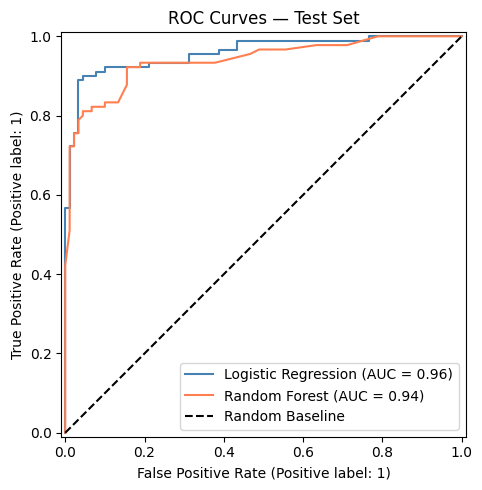

In [50]:
# a single figure created to overlay the ROC curves for comparison
fig, ax = plt.subplots(figsize=(7, 5))
# Loops through each trained model to calculate and draw its specific curve
for name, model, color in [("Logistic Regression", lr_model, 'steelblue'),
                            ("Random Forest", rf_model, 'coral')]:
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, # Generates the ROC curve using the test data
                                   name=name, curve_kwargs={"color": color})

ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline') # draws a diagonal dashed line to represent a random classifier that acts as a benchmark
ax.set_title("ROC Curves — Test Set")
ax.legend()
plt.tight_layout()
plt.show()

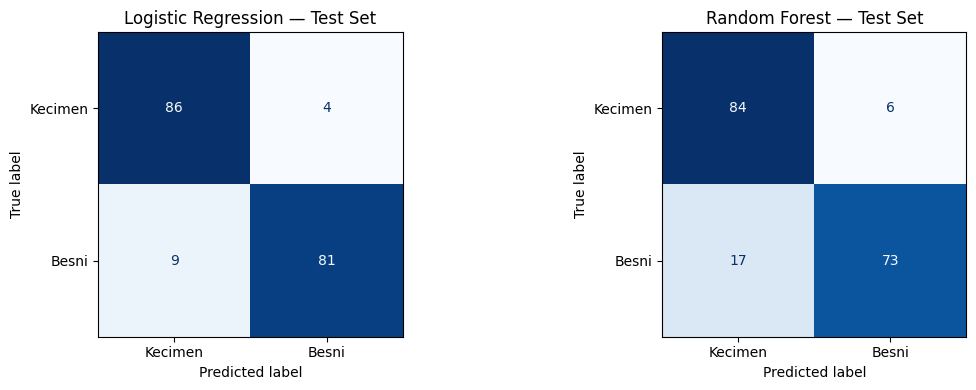

In [51]:
# Confusion Matrices (test set)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, model) in zip(axes, [("Logistic Regression", lr_model),
                                      ("Random Forest", rf_model)]):
# Generates the matrix using the test data
# Kecimen is 0 while Besni is 1
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=["Kecimen", "Besni"],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f"{name} — Test Set")
plt.tight_layout()
plt.show()

In [14]:
# Detailed classification reports
for name, model in [("Logistic Regression", lr_model), ("Random Forest", rf_model)]:
    print(f"=== {name} ===")
    print(classification_report(y_test, model.predict(X_test),
                                 target_names=["Kecimen", "Besni"]))

=== Logistic Regression ===
              precision    recall  f1-score   support

     Kecimen       0.91      0.96      0.93        90
       Besni       0.95      0.90      0.93        90

    accuracy                           0.93       180
   macro avg       0.93      0.93      0.93       180
weighted avg       0.93      0.93      0.93       180

=== Random Forest ===
              precision    recall  f1-score   support

     Kecimen       0.83      0.93      0.88        90
       Besni       0.92      0.81      0.86        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



### 4d. Generate Kaggle Submission File

In [53]:
# Uses best model which is lr since it has a higher AUC score by 0.02
best_model = lr_model   # model that had the highest ROC-AUC score is chosen

# Generates the final predictions and confidence scores on the test set
test_preds = best_model.predict(X_test)
test_probs = best_model.predict_proba(X_test)[:, 1]

# Creates a table to organize the findings
# Includes an ID, the variety prediction, and how the model's probability
submission = pd.DataFrame({
    'Id': range(1, len(test_preds) + 1),
    'Predicted_Class': test_preds,   # 0 = Kecimen, 1 = Besni
    'Probability_Besni': test_probs
})

print("Submission preview:")
display(submission.head())

submission.to_csv('raisin_kaggle_submission.csv', index=False)
print("\nSaved: raisin_kaggle_submission.csv")

Submission preview:


,Id,Predicted_Class,Probability_Besni
0,1,0,0.448329
1,2,0,0.068165
2,3,0,0.014448
3,4,1,0.989780
4,5,0,0.061765



Saved: raisin_kaggle_submission.csv
